## Setup

In [74]:
from os import path
import rasterio
import numpy as np
import glob
import os
import torch
from torchgeo.models import croma_base, CROMABase_Weights

PATCH_SIZE = 8
EMBED_DIM = 768
TILE_SIZE = 120
GRID_SIZE = TILE_SIZE // PATCH_SIZE     # 15

device = torch.device("cpu")
print(f"Device: {device}")

def load_tile(path, band_indices=None):
    with rasterio.open(path) as src:
        if band_indices is None:
            data = src.read().astype(np.float32)
        else:
            data = src.read([i + 1 for i in band_indices]).astype(np.float32)
    return data

folder = "/Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/data_img/croma_cloud_eval"

Device: cpu


## Upload the tiles

In [75]:
#just optical — orden explícito: ground_true (baseline) -> clouds -> haze
ORDER_S2 = ["s2_ground_true.tif", "s2_clouds.tif", "s2_haze.tif"]

tiles = {}
for name in ORDER_S2:
    tiles[name] = load_tile(os.path.join(folder, name))

In [76]:
# check max and min of the optical tiles
for name, tile in tiles.items():
    print(f"Tile {name} has max value {tile.max()} and min value {tile.min()}")


Tile s2_ground_true.tif has max value 4902.0 and min value 102.0
Tile s2_clouds.tif has max value 5957.0 and min value 93.0
Tile s2_haze.tif has max value 5444.0 and min value 220.0


## Visualization of the tiles

In [77]:
import rasterio

path_tile = "/Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/data_img/croma_cloud_eval/s2_ground_true.tif"

with rasterio.open(path_tile) as src:
    print(f"Number of bands: {src.count}")
    print(f"Dimensions (height x width): {src.height} x {src.width}")
    print(f"Resolution (x, y): {src.res}")
    print(f"CRS: {src.crs}")
    print(f"Transform: {src.transform}")
    print(f"Data types by band: {src.dtypes}")
    print(f"Band names/descriptions: {src.descriptions}")

Number of bands: 12
Dimensions (height x width): 120 x 120
Resolution (x, y): (9.95908995376473, 9.951647785802683)
CRS: EPSG:32720
Transform: | 9.96, 0.00, 666247.15|
| 0.00,-9.95, 8622735.44|
| 0.00, 0.00, 1.00|
Data types by band: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')
Band names/descriptions: ('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12')


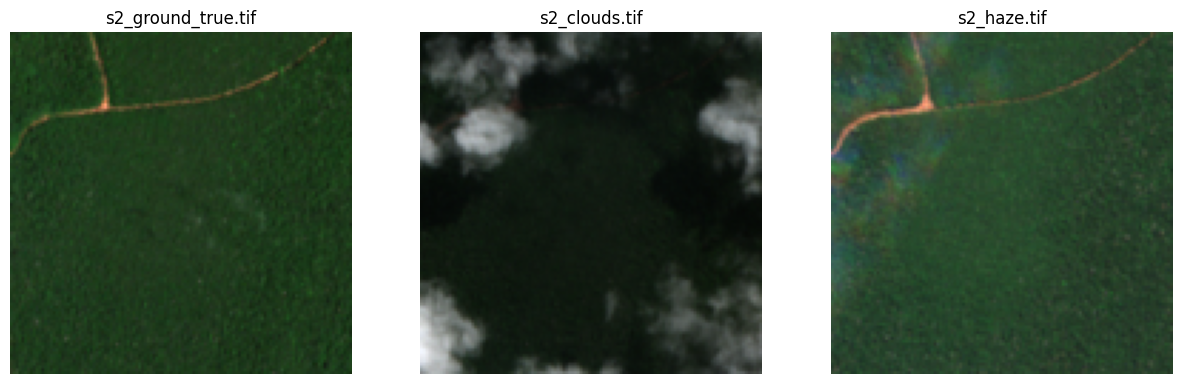

In [78]:
import math
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, tile) in zip(axes, tiles.items()):
    rgb = tile[[3, 2, 1]].transpose(1, 2, 0) #  b4, b3, b2 in the format (H, W, 3)
    rgb = rgb / rgb.max()                     # normalizar a 0-1
    ax.imshow(rgb)
    ax.set_title(name)
    ax.axis("off")

plt.show()

## Global stats

In [79]:
def compute_global_stats(folder, band_indices=None, min_valid=None, max_valid=None, pattern="s2_*.tif"):
    paths = sorted(glob.glob(os.path.join(folder, pattern)))
    if not paths:
        raise FileNotFoundError(f"No tiles found in: {folder} with pattern {pattern}")

    if band_indices is None:
        with rasterio.open(paths[0]) as src:
            band_indices = list(range(src.count))

    C = len(band_indices)
    sum_   = np.zeros(C, dtype=np.float64)
    sum_sq = np.zeros(C, dtype=np.float64)
    count  = np.zeros(C, dtype=np.int64)

    for p in paths:
        data = load_tile(p, band_indices=band_indices)
        valid = np.isfinite(data)
        if min_valid is not None:
            valid &= (data > min_valid)
        if max_valid is not None:
            valid &= (data < max_valid)

        d = np.where(valid, data, 0.0).astype(np.float64)
        sum_   += d.sum(axis=(1, 2))
        sum_sq += (d * d).sum(axis=(1, 2))
        count  += valid.sum(axis=(1, 2)).astype(np.int64)

    mean = sum_ / np.maximum(count, 1)
    var  = sum_sq / np.maximum(count, 1) - mean ** 2
    std  = np.sqrt(np.maximum(var, 0.0))
    return mean.astype(np.float32), std.astype(np.float32), len(paths)

In [80]:
band_indices = list(range(12))   # B1..B12 (sin B10)
band_names   = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B11","B12"]

mean, std, n_tiles = compute_global_stats(
    folder,
    band_indices=band_indices,
    min_valid=0       # descarta píxeles negativos / no-data
)

print(f"Tiles procesados: {n_tiles}")
for i, b in enumerate(band_names):
    print(f"{b}: mean={mean[i]:.2f}  std={std[i]:.2f}")

Tiles procesados: 4
B1: mean=1441.57  std=1815.32
B2: mean=1394.05  std=1808.02
B3: mean=1507.09  std=1695.71
B4: mean=1345.29  std=1737.90
B5: mean=1860.49  std=1713.22
B6: mean=3085.12  std=1263.89
B7: mean=3587.98  std=1226.29
B8: mean=3473.13  std=1133.48
B8A: mean=3855.11  std=1148.43
B9: mean=4969.87  std=3054.41
B11: mean=2414.13  std=1154.65
B12: mean=1507.45  std=1263.86


## Normalize

In [81]:
def normalize(x, mean, std):
    """CROMA recipe with global stats: clip to mean ± 2*std per channel, rescale to [0, 1].

    x:    (N, C, H, W) tensor
    mean: (C,) tensor or array
    std:  (C,) tensor or array
    """
    x = x.float()
    mean = torch.as_tensor(mean, dtype=x.dtype, device=x.device).view(1, -1, 1, 1)
    std = torch.as_tensor(std, dtype=x.dtype, device=x.device).view(1, -1, 1, 1)
    min_val = mean - 2 * std
    max_val = mean + 2 * std
    x = (x - min_val) / (max_val - min_val)
    return torch.clamp(x, 0, 1)

## Encoder helper

In [82]:
def encode(model, x_normalized, modality):
    """Forward pass on a normalized batch. Returns (N, 15, 15, 768) tokens."""
    captured = {}
    encoder = model.s2_encoder if modality == "optical" else model.s1_encoder

    def hook(module, inp, out):
        captured["tokens"] = out

    h = encoder.register_forward_hook(hook)
    with torch.no_grad():
        if modality == "optical":
            _ = model(x_optical=x_normalized)
        else:
            _ = model(x_sar=x_normalized)
    h.remove()

    out = captured["tokens"]
    if isinstance(out, tuple):
        out = out[0]
    tokens = out.cpu().numpy()
    if tokens.ndim == 2:
        tokens = tokens[None]
    expected = GRID_SIZE * GRID_SIZE
    if tokens.shape[1] == expected + 1:
        tokens = tokens[:, 1:]
    return tokens.reshape(-1, GRID_SIZE, GRID_SIZE, EMBED_DIM)

## Load CROMA models

In [83]:
model = croma_base(
    weights=CROMABase_Weights.CROMA_VIT,
    modalities=["optical"],
    image_size=120,
).to(device).eval()
print("CROMA optical model loaded")

CROMA optical model loaded


In [84]:
from torchgeo.models import croma_base, CROMABase_Weights

model_joint = croma_base(
    weights     = CROMABase_Weights.CROMA_VIT,
    modalities  = ["sar", "optical"],
    image_size  = 120,
).to(device).eval()
print("CROMA joint model loaded.")

CROMA joint model loaded.


In [85]:
model_sar = croma_base(
    weights    = CROMABase_Weights.CROMA_VIT,
    modalities = ["sar"],
    image_size = 120,
).to(device).eval()
print("CROMA SAR model loaded")

CROMA SAR model loaded


## Creation of the embeddings

### Creation of the tensor with the data

In [86]:
MODALITY = "optical"  

# 1) Build (N, 12, 120, 120) tensor
all_data = np.stack(list(tiles.values()), axis=0).astype(np.float32)
tile_names = list(tiles.keys())
print(f"Input shape: {all_data.shape}, order: {tile_names}")

# 2) Normalize + encode (usando mean/std globales ya calculados)
x = torch.from_numpy(all_data)
x = normalize(x, mean, std).to(device)
tokens = encode(model, x, MODALITY)          # (N, 15, 15, 768)
print(f"Tokens shape: {tokens.shape}")

Input shape: (3, 12, 120, 120), order: ['s2_ground_true.tif', 's2_clouds.tif', 's2_haze.tif']
Tokens shape: (3, 15, 15, 768)


flat shape: (675, 768)
Explained variance: [0.22056432 0.09149278 0.08063495]
Cumulative:         0.393


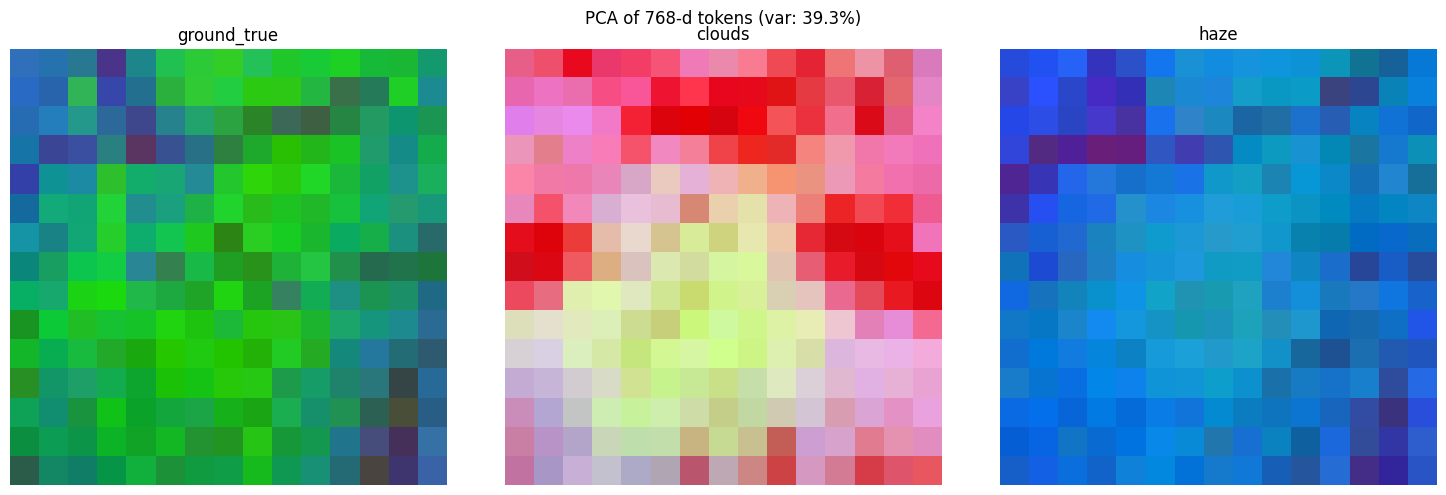

In [87]:
from sklearn.decomposition import PCA

N = tokens.shape[0]      # 3 tiles

# 1) Flatten todos los tokens (N*15*15, 768)
flat = tokens.reshape(-1, EMBED_DIM)
print("flat shape:", flat.shape)

# 2) Fit PCA: find the 3 directions in 768-D space along which patches vary most.
pca = PCA(n_components=3, whiten=True)
projected = pca.fit_transform(flat)                  # (N_patches, 3)
print(f"Explained variance: {pca.explained_variance_ratio_}")
print(f"Cumulative:         {pca.explained_variance_ratio_.sum():.3f}")

# 3) Put the 3 components back into the spatial grid.
pca_rgb = projected.reshape(N, GRID_SIZE, GRID_SIZE, 3)

for c in range(3):
      ch = pca_rgb[..., c]
      pca_rgb[..., c] = (ch - ch.min()) / (ch.max() - ch.min())

# 4) Plot the 3 tiles side by side
short = [n.replace("s2_", "").replace(".tif", "") for n in tile_names]

fig, axes = plt.subplots(1, N, figsize=(5*N, 5))
for i in range(N):
     axes[i].imshow(pca_rgb[i])
     axes[i].set_title(short[i])
     axes[i].axis("off")
fig.suptitle(f"PCA of 768-d tokens (var: {pca.explained_variance_ratio_.sum():.1%})")
plt.tight_layout()  
plt.show()

In [88]:
# Embedding por tile = promedio de sus 225 parches
tile_embed = tokens.mean(axis=(1, 2))   # (3, 768) 

# Cosine similarity 3x3
emb_n   = tile_embed / np.linalg.norm(tile_embed, axis=1, keepdims=True) #magnitude (largo) of the embeddings, the tile_embed is divide per length of the vector to normalize it
cos_sim = emb_n @ emb_n.T #dot product of the embeddings

In [89]:
# L2 distance vs tile limpio  
l2 = np.linalg.norm(tile_embed - tile_embed[0], axis=1)

print("Cosine similarity:")
print(np.round(cos_sim, 3))   
print("\nL2 distance vs clean tile:")
for n, v in zip(tile_names, l2):
    print(f"  {n}: {v:.3f}")

Cosine similarity:
[[1.    0.459 0.811]
 [0.459 1.    0.412]
 [0.811 0.412 1.   ]]

L2 distance vs clean tile:
  s2_ground_true.tif: 0.000
  s2_clouds.tif: 21.147
  s2_haze.tif: 13.267


# SAR & Joint

In [90]:
# Upload the SAR tiles — orden explícito: ground_true (baseline) -> clouds -> haze
ORDER_S1 = ["s1_ground_true.tif", "s1_clouds.tif", "s1_haze.tif"]

tiles_sar = {}
for name in ORDER_S1:
    tiles_sar[name] = load_tile(os.path.join(folder, name))

#stats SAR
s1_mean, s1_std, _ = compute_global_stats(folder, band_indices=[0,1], pattern="s1_*.tif")
print(f"S1 mean: {s1_mean}, std: {s1_std}")

#Build SAR tensor
all_sar = np.stack(list(tiles_sar.values()), axis=0).astype(np.float32)
sar_names = list(tiles_sar.keys())
print(f"SAR tensor shape: {all_sar.shape}, order: {sar_names}")

#Normalize SAR
x_s1 = normalize(torch.from_numpy(all_sar), s1_mean, s1_std).to(device)

#Encode SAR
tokens_sar = encode(model_sar, x_s1, "sar")
print(f"Tokens shape: {tokens_sar.shape}")

S1 mean: [ -7.9416833 -14.011919 ], std: [2.0130734 2.1325133]
SAR tensor shape: (3, 2, 120, 120), order: ['s1_ground_true.tif', 's1_clouds.tif', 's1_haze.tif']
Tokens shape: (3, 15, 15, 768)


flat shape: (675, 768)
Explained variance: [0.13150574 0.1231833  0.07398241]
Cumulative:         0.329


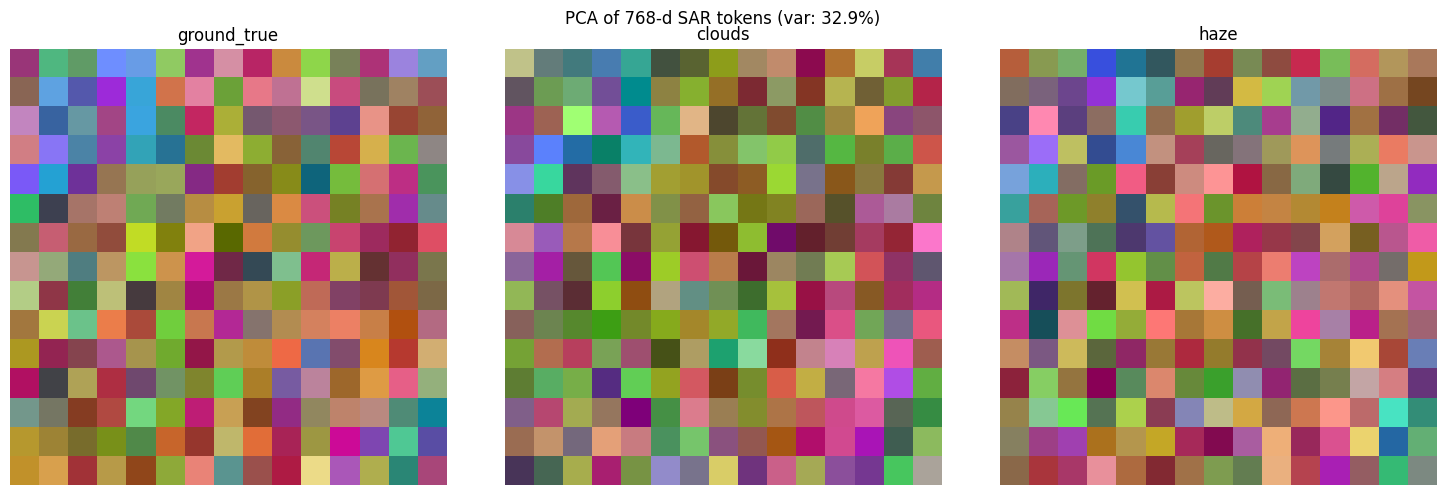

In [91]:
N = tokens_sar.shape[0]      # 3 tiles

# 1) Flatten todos los tokens (N*15*15, 768)
flat = tokens_sar.reshape(-1, EMBED_DIM)
print("flat shape:", flat.shape)

# 2) Fit PCA: find the 3 directions in 768-D space along which patches vary most.
pca_sar = PCA(n_components=3, whiten=True)
projected_sar = pca_sar.fit_transform(flat)                  # (N_patches, 3)
print(f"Explained variance: {pca_sar.explained_variance_ratio_}")
print(f"Cumulative:         {pca_sar.explained_variance_ratio_.sum():.3f}")

# 3) Put the 3 components back into the spatial grid.
pca_rgb_sar = projected_sar.reshape(N, GRID_SIZE, GRID_SIZE, 3)

for c in range(3):
      ch = pca_rgb_sar[..., c]
      pca_rgb_sar[..., c] = (ch - ch.min()) / (ch.max() - ch.min())

# 4) Plot the 3 tiles side by side
short = [n.replace("s1_", "").replace(".tif", "") for n in sar_names]

fig, axes = plt.subplots(1, N, figsize=(5*N, 5))
for i in range(N):
     axes[i].imshow(pca_rgb_sar[i])
     axes[i].set_title(short[i])
     axes[i].axis("off")
fig.suptitle(f"PCA of 768-d SAR tokens (var: {pca_sar.explained_variance_ratio_.sum():.1%})")
plt.tight_layout()  
plt.show()

# Joint embedding

In [92]:
def encode_joint(model, x_optical, x_sar):
    """Forward pass joint. Returns (N, 15, 15, 768) joint tokens."""
    captured = {}
    encoder = model.joint_encoder

    def hook(module, inp, out):
        captured["tokens"] = out

    h = encoder.register_forward_hook(hook)
    with torch.no_grad():
        _ = model(x_optical=x_optical, x_sar=x_sar)
    h.remove()

    out = captured["tokens"]
    if isinstance(out, tuple):
        out = out[0]
    tokens = out.cpu().numpy()
    if tokens.ndim == 2:
        tokens = tokens[None]
    expected = GRID_SIZE * GRID_SIZE
    if tokens.shape[1] == expected + 1:
        tokens = tokens[:, 1:]
    return tokens.reshape(-1, GRID_SIZE, GRID_SIZE, EMBED_DIM)

In [93]:
# Verificar orden S2 ↔ S1
print("S2 order:", tile_names)
print("S1 order:", sar_names)

tokens_joint = encode_joint(model_joint, x, x_s1)
print(f"Joint tokens shape: {tokens_joint.shape}")

S2 order: ['s2_ground_true.tif', 's2_clouds.tif', 's2_haze.tif']
S1 order: ['s1_ground_true.tif', 's1_clouds.tif', 's1_haze.tif']
Joint tokens shape: (3, 15, 15, 768)


flat shape: (675, 768)
Explained variance: [0.14998369 0.07594167 0.05530855]
Cumulative:         0.281


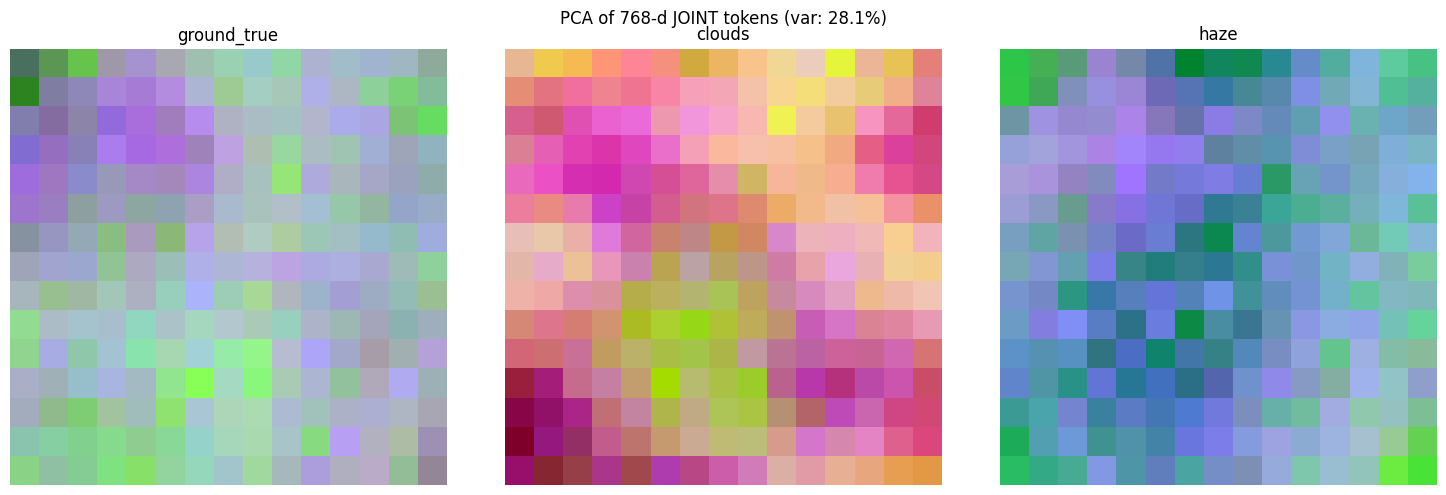

In [94]:
N = tokens_joint.shape[0]

flat = tokens_joint.reshape(-1, EMBED_DIM)
print("flat shape:", flat.shape)

pca_joint = PCA(n_components=3, whiten=True)
projected_joint = pca_joint.fit_transform(flat)
print(f"Explained variance: {pca_joint.explained_variance_ratio_}")
print(f"Cumulative:         {pca_joint.explained_variance_ratio_.sum():.3f}")

pca_rgb_joint = projected_joint.reshape(N, GRID_SIZE, GRID_SIZE, 3)

for c in range(3):
    ch = pca_rgb_joint[..., c]
    pca_rgb_joint[..., c] = (ch - ch.min()) / (ch.max() - ch.min())

short = [n.replace("s2_", "").replace(".tif", "") for n in tile_names]

fig, axes = plt.subplots(1, N, figsize=(5*N, 5))
for i in range(N):
    axes[i].imshow(pca_rgb_joint[i])
    axes[i].set_title(short[i])
    axes[i].axis("off")
fig.suptitle(f"PCA of 768-d JOINT tokens (var: {pca_joint.explained_variance_ratio_.sum():.1%})")
plt.tight_layout()
plt.show()

In [95]:
tile_embed_joint = tokens_joint.mean(axis=(1, 2))                  # (3, 768)

emb_n = tile_embed_joint / np.linalg.norm(tile_embed_joint, axis=1, keepdims=True)
cos_sim_joint = emb_n @ emb_n.T

l2_joint = np.linalg.norm(tile_embed_joint - tile_embed_joint[0], axis=1)

print("Cosine similarity (JOINT):")
print(np.round(cos_sim_joint, 3))
print("\nL2 distance vs clean tile (JOINT):")
for n, v in zip(tile_names, l2_joint):
    print(f"  {n}: {v:.3f}")

Cosine similarity (JOINT):
[[1.    0.929 0.939]
 [0.929 1.    0.868]
 [0.939 0.868 1.   ]]

L2 distance vs clean tile (JOINT):
  s2_ground_true.tif: 0.000
  s2_clouds.tif: 8.716
  s2_haze.tif: 8.125


In [96]:
# Embedding por tile = promedio de sus 225 parches
tile_embed_sar = tokens_sar.mean(axis=(1, 2))   # (3, 768) 

# Cosine similarity 3x3
emb_n_sar   = tile_embed_sar / np.linalg.norm(tile_embed_sar, axis=1, keepdims=True) #magnitude (largo) of the embeddings, the tile_embed is divide per length of the vector to normalize it
cos_sim_sar = emb_n_sar @ emb_n_sar.T #dot product of the embeddings
l2_sar = np.linalg.norm(tile_embed_sar - tile_embed_sar[0], axis=1)

print("Cosine similarity:")
print(np.round(cos_sim_sar, 3))   
print("\nL2 distance vs clean tile:")
for n, v in zip(sar_names, l2_sar):
    print(f"  {n}: {v:.3f}")

Cosine similarity:
[[1.    0.989 0.996]
 [0.989 1.    0.985]
 [0.996 0.985 1.   ]]

L2 distance vs clean tile:
  s1_ground_true.tif: 0.000
  s1_clouds.tif: 3.541
  s1_haze.tif: 2.135


In [97]:
def normalized_l2(tile_embed):
      baseline_norm = np.linalg.norm(tile_embed[0])
      return np.linalg.norm(tile_embed - tile_embed[0], axis=1) /baseline_norm
  
print(f"{'Tile':<25} {'Optical':>10} {'SAR':>10} {'Joint':>10}")
print("-" * 60)
for i, n in enumerate(tile_names):
    print(f"{n:<25} "
        f"{normalized_l2(tile_embed)[i]:>10.4f} "
        f"{normalized_l2(tokens_sar.mean(axis=(1,2)))[i]:>10.4f} "
        f"{normalized_l2(tile_embed_joint)[i]:>10.4f}")

Tile                         Optical        SAR      Joint
------------------------------------------------------------
s2_ground_true.tif            0.0000     0.0000     0.0000
s2_clouds.tif                 0.9667     0.1511     0.3713
s2_haze.tif                   0.6065     0.0911     0.3461


# Synthetic clouds generation (S2)

- Clouds: binary mask from B2 brightness difference (clouds - ground_true). Subsample/bootstrap to target N% area coverage.
- Seed fijo (42) to reproduce. Metadata (CRS, transform, dtype) preservada del ground truth.

In [98]:
from functools import partial
from scipy.ndimage import gaussian_filter

np.random.seed(42)

eval_folder = "/Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/data_img/croma_cloud_eval"
clouds_out  = os.path.join(eval_folder, "synth_clouds")
os.makedirs(clouds_out, exist_ok=True)


with rasterio.open(os.path.join(eval_folder, "s2_ground_true.tif")) as src:
    gt = src.read().astype(np.float32)
    profile = src.profile.copy()
with rasterio.open(os.path.join(eval_folder, "s2_clouds.tif")) as src:
    cl = src.read().astype(np.float32)


C, H, W = gt.shape

#natural cloud percentage obtained from the source tile downloaded from GEE
NATURAL_CLOUD_PCT = 11.1
SIGMA = 8  # blob size: bigger -> larger, smoother clusters

#print(cl[0].shape)

# number of pixels with natural cloud coverage
n_target_natural = int(round(NATURAL_CLOUD_PCT / 100 * H * W))
print (n_target_natural)

1598


In [99]:
from scipy.ndimage import gaussian_filter

np.random.seed(42)

eval_folder = "/Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/data_img/croma_cloud_eval"
clouds_out  = os.path.join(eval_folder, "synth_clouds")
os.makedirs(clouds_out, exist_ok=True)


with rasterio.open(os.path.join(eval_folder, "s2_ground_true.tif")) as src:
    gt = src.read().astype(np.float32)
    profile = src.profile.copy()
with rasterio.open(os.path.join(eval_folder, "s2_clouds.tif")) as src:
    cl = src.read().astype(np.float32)


C, H, W = gt.shape

#natural cloud percentage obtained from the source tile downloaded from GEE
NATURAL_CLOUD_PCT = 11.1
SIGMA = 8  # blob size: bigger -> larger, smoother clusters

# Identify natural cloud pixels (top NATURAL_CLOUD_PCT% by B2 brightness diff)
#uses b2 (blue) band to identify the cloud pixels
cloud_diff = cl[1] - gt[1]
print(cloud_diff)
# number of pixels with natural cloud coverage
n_target_natural = int(round(NATURAL_CLOUD_PCT / 100 * H * W)) #1598
#threshold to identify the cloud pixels
threshold_natural = np.partition(cloud_diff.flatten(), -n_target_natural)[-n_target_natural]
print(threshold_natural)
cloud_mask_natural = cloud_diff >= threshold_natural
#print(cloud_mask_natural)
cloud_pixel_values = cl[:, cloud_mask_natural]   # (C, n_cloud_natural) joint per-pixel values
#print(f"Natural cloud pixels identified: {cloud_pixel_values.shape[1]} ({100*cloud_pixel_values.shape[1]/(H*W):.2f}%)")

percentages = list(range(10, 101, 10))

# --- CLOUDS: Gaussian random field mask + joint cloud-pixel sampling ---
for pct in percentages:
    # 1) Clustered mask: smooth random field, threshold so exactly pct% pixels are True
    field = gaussian_filter(np.random.randn(H, W), sigma=SIGMA)
    cutoff = np.percentile(field, 100 - pct)
    mask = field >= cutoff

    # 2) Fill mask pixels by sampling joint (12-band) values from natural cloud distribution
    n_mask = int(mask.sum())
    sample_idx = np.random.choice(cloud_pixel_values.shape[1], n_mask, replace=True)
    sampled = cloud_pixel_values[:, sample_idx]    # (C, n_mask) preserves inter-band correlation

    synth = gt.copy()
    synth[:, mask] = sampled
    synth = np.clip(synth, 0, np.iinfo(profile["dtype"]).max).astype(profile["dtype"])

    out_path = os.path.join(clouds_out, f"s2_clouds_{pct:03d}.tif")
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(synth)

print(f"Saved {len(percentages)} cloud tiles to {clouds_out}")


[[  23.   51.   15. ... 1322. 1450. 1363.]
 [  10.    6.   14. ... 1300. 1218. 1211.]
 [ -15.   -5.   92. ...  952.  907. 1065.]
 ...
 [3233. 3342. 3300. ...  745.  746.  735.]
 [2702. 3021. 3014. ...  742.  795.  923.]
 [2329. 2542. 2650. ...  974. 1022. 1248.]]
1174.0
Saved 10 cloud tiles to /Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/data_img/croma_cloud_eval/synth_clouds


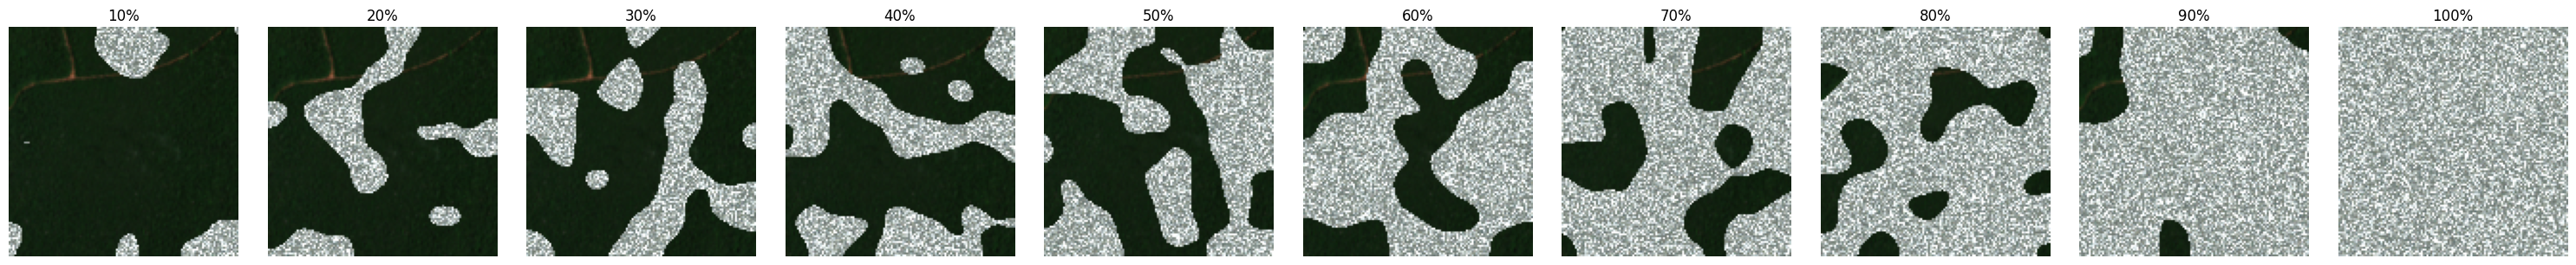

In [100]:
check_pcts = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
fig, axes = plt.subplots(1, len(check_pcts), figsize=(3 * len(check_pcts), 3))

for j, pct in enumerate(check_pcts):
    with rasterio.open(os.path.join(clouds_out, f"s2_clouds_{pct:03d}.tif")) as src:
        rgb = src.read([4, 3, 2]).astype(np.float32).transpose(1, 2, 0)
    rgb = np.clip(rgb / 3000, 0, 1)
    axes[j].imshow(rgb)
    axes[j].set_title(f"{pct}%")
    axes[j].axis("off")

plt.tight_layout()
plt.show()

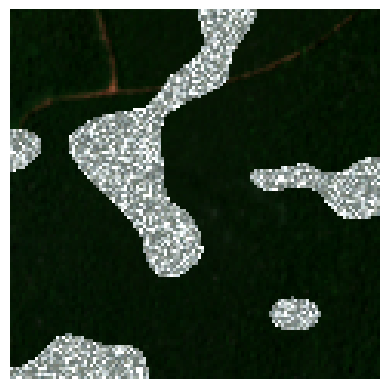

In [101]:
image = rasterio.open(os.path.join(clouds_out, f"s2_clouds_020.tif"))
rgb = image.read([4, 3, 2]).astype(np.float32).transpose(1, 2, 0)
p2, p98 = np.percentile(rgb, [2, 98])
rgb = np.clip((rgb - p2) / (p98-p2), 0, 1)
plt.imshow(rgb)
plt.axis("off")
plt.show()


# Synthetic clouds: copy & paste de píxeles reales (tile 100% clouds)

 Usa `s2_cloudy_100_20180212.tif`: un tile **del mismo área con ~100% de nube**. Para cada porcentaje (10–100%) se construye una máscara agrupada (Gaussian random field) y se **copia el píxel de nube real en su misma posición** sobre el ground truth limpio. Así se preserva la estructura espacial y la firma espectral real de la nube. Al 100% la máscara cubre todo, así que el resultado es el tile nublado completo.

In [104]:
from scipy.ndimage import gaussian_filter

np.random.seed(42)

eval_folder   = "/Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/data_img/croma_cloud_eval"
clouds_out_v3 = os.path.join(eval_folder, "synth_clouds_v3")
os.makedirs(clouds_out_v3, exist_ok=True)

# ground truth limpio + tile REAL con ~100% de nube (mismo área)
with rasterio.open(os.path.join(eval_folder, "s2_ground_true.tif")) as src:
    gt = src.read().astype(np.float32)
    profile = src.profile.copy()
with rasterio.open(os.path.join(eval_folder, "s2_cloudy_100_20180212.tif")) as src:
    cloudy = src.read().astype(np.float32)

assert cloudy.shape == gt.shape, f"shapes distintos: {cloudy.shape} vs {gt.shape}"
C, H, W = gt.shape
SIGMA = 8  # tamaño de blob: más grande -> nubes más grandes y suaves

percentages = list(range(10, 101, 10))

# Para cada %: máscara agrupada + COPIAR el píxel de nube real en su MISMA posición
for pct in percentages:
    field  = gaussian_filter(np.random.randn(H, W), sigma=SIGMA)
    cutoff = np.percentile(field, 100 - pct)
    mask   = field >= cutoff                       # ~pct% de píxeles True

    # copy & paste: donde mask=True uso el píxel real de la nube, si no el ground truth
    synth = np.where(mask[None, :, :], cloudy, gt)
    synth = np.clip(synth, 0, np.iinfo(profile["dtype"]).max).astype(profile["dtype"])

    out_path = os.path.join(clouds_out_v3, f"s2_clouds_{pct:03d}.tif")
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(synth)

print(f"Saved {len(percentages)} cloud tiles to {clouds_out_v3}")

Saved 10 cloud tiles to /Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/data_img/croma_cloud_eval/synth_clouds_v3


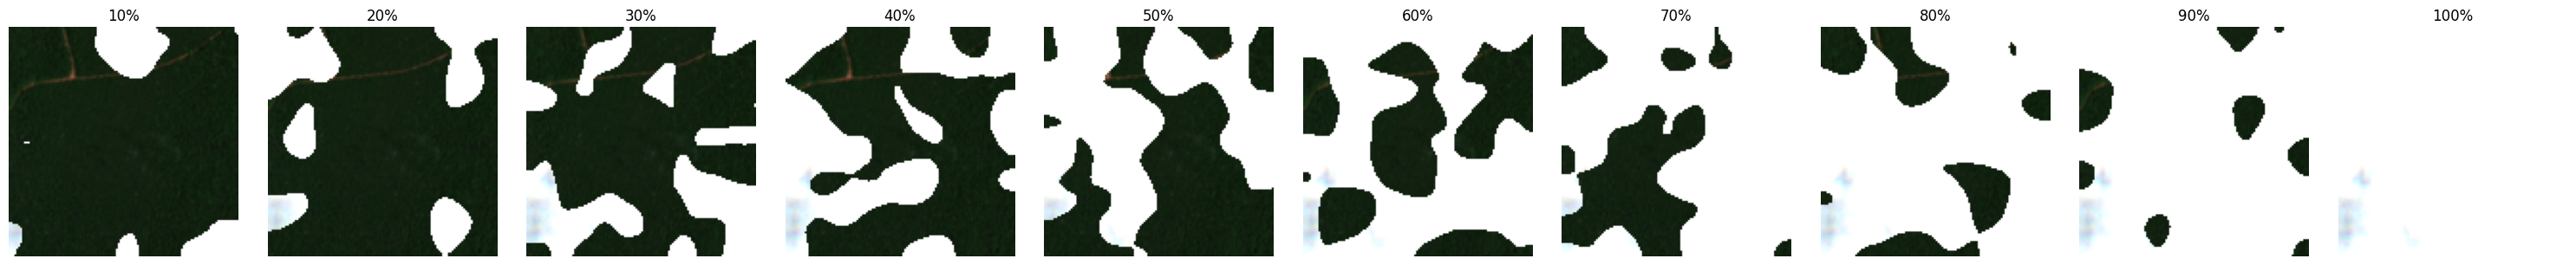

In [105]:
# Visualizar v3
check_pcts = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
fig, axes = plt.subplots(1, len(check_pcts), figsize=(3 * len(check_pcts), 3))

for j, pct in enumerate(check_pcts):
    with rasterio.open(os.path.join(clouds_out_v3, f"s2_clouds_{pct:03d}.tif")) as src:
        rgb = src.read([4, 3, 2]).astype(np.float32).transpose(1, 2, 0)
    rgb = np.clip(rgb / 3000, 0, 1)
    axes[j].imshow(rgb)
    axes[j].set_title(f"{pct}%")
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Analysis of embeddings effects
1. Generate the optical embeddings from the images
3. Create the joint embeddings using the ground true sentinel 1

In [106]:
# Optical sequence: 0% (clean ground truth) + 10..100%
opt_paths = [os.path.join(folder, "s2_ground_true.tif")] + \
            [os.path.join(clouds_out_v3, f"s2_clouds_{p:03d}.tif") for p in range(10, 101, 10)]
pcts = [0] + list(range(10, 101, 10))
opt = np.stack([load_tile(p) for p in opt_paths]).astype(np.float32)   # (11,12,120,120)



In [107]:
# Fixed SAR = ground truth, repeated for every cloud level
sar_gt = load_tile(os.path.join(folder, "s1_ground_true.tif"), band_indices=[0, 1]).astype(np.float32)
sar = np.repeat(sar_gt[None], len(opt_paths), axis=0) 

In [108]:
# Global stats + normalize
s2_mean, s2_std, _ = compute_global_stats(folder, band_indices=list(range(12)), pattern="s2_*.tif")
s1_mean, s1_std, _ = compute_global_stats(folder, band_indices=[0, 1], pattern="s1_*.tif")
x_opt = normalize(torch.from_numpy(opt), s2_mean, s2_std).to(device)
x_sar = normalize(torch.from_numpy(sar), s1_mean, s1_std).to(device)

In [110]:
from numpy.linalg import norm
# Embeddings: joint (optical + fixed SAR) and optical-only (for comparison)
tok_joint = encode_joint(model_joint, x_opt, x_sar)       # (11,15,15,768)
tok_opt   = encode(model, x_opt, "optical")         # (11,15,15,768)

def mean_cos_vs_clean(tok):   
    clean = tok[0].reshape(-1, EMBED_DIM)                  # 0% = reference
    return np.array([
        ((clean * tok[i].reshape(-1, EMBED_DIM)).sum(1) /
        (norm(clean, axis=1) * norm(tok[i].reshape(-1, EMBED_DIM), axis=1) + 1e-9)).mean()
        for i in range(tok.shape[0])
    ])    

cos_joint = mean_cos_vs_clean(tok_joint)
cos_opt   = mean_cos_vs_clean(tok_opt)

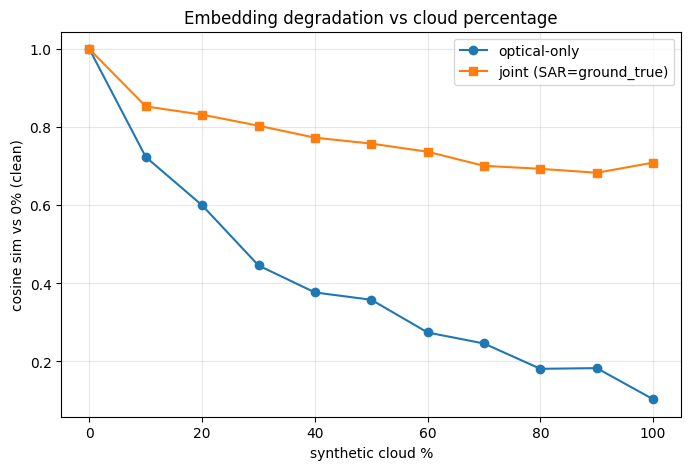

  0% -> joint=1.0000   optical=1.0000
 10% -> joint=0.8534   optical=0.7237
 20% -> joint=0.8323   optical=0.6000
 30% -> joint=0.8040   optical=0.4459
 40% -> joint=0.7734   optical=0.3768
 50% -> joint=0.7582   optical=0.3581
 60% -> joint=0.7373   optical=0.2742
 70% -> joint=0.7013   optical=0.2461
 80% -> joint=0.6936   optical=0.1812
 90% -> joint=0.6835   optical=0.1830
100% -> joint=0.7093   optical=0.1033


In [111]:
# Plot: embedding degradation vs cloud percentage
plt.figure(figsize=(8, 5))
plt.plot(pcts, cos_opt,   "o-", label="optical-only")
plt.plot(pcts, cos_joint, "s-", label="joint (SAR=ground_true)")
plt.xlabel("synthetic cloud %"); plt.ylabel("cosine sim vs 0% (clean)")
plt.title("Embedding degradation vs cloud percentage")
plt.grid(alpha=0.3); plt.legend(); plt.show()

for p, cj, co in zip(pcts, cos_joint, cos_opt):
    print(f"{p:3d}% -> joint={cj:.4f}   optical={co:.4f}")